In [1]:
%load_ext jupyter_black

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

# Prepare the data set
Split data into three sub-data set: (train, val) and test. The latter will be used to test the model accuracy once the full model is learned. The formers will be used to train the model and evaluate the convergence/overfitting along the iteration.

In [33]:
# load data
val_percent_size = 0.20
test_percent_size = 0.20
X, y = fetch_california_housing(return_X_y=True)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=test_percent_size, random_state=0
)  # We keep 20% of data set to test
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=val_percent_size, random_state=0
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [34]:
print(
    f"The number of sample for training, validation and test are {X_train.shape[0]}, {X_test.shape[0]}, {X_test.shape[0]}, respectively."
)

The number of sample for training, validation and test are 13209, 4128, 4128, respectively.


We transform numpy array to pytorch tensor

In [35]:
X_train, y_train = torch.from_numpy(X_train).to(torch.float32), torch.from_numpy(
    y_train
).to(torch.float32).unsqueeze(1)
X_val, y_val = torch.from_numpy(X_val).to(torch.float32), torch.from_numpy(y_val).to(
    torch.float32
).unsqueeze(1)
X_test, y_test = torch.from_numpy(X_test).to(torch.float32), torch.from_numpy(
    y_test
).to(torch.float32).unsqueeze(1)

We now define the pytorch dataloaders that will be used during the optimization.

In [36]:
batch_size = 256
train_set = DataLoader(
    TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True
)
val_set = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size, shuffle=False)
test_set = DataLoader(
    TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False
)

# Define the Regression Model

In [37]:
class RegressionModel(nn.Module):
    def __init__(self, input_size: int = 1):
        super(RegressionModel, self).__init__()
        self.linear = nn.Linear(input_size, 1)

    def forward(self, X: torch.tensor) -> torch.Tensor:
        return self.linear(X)

# Optimization
As for the linear 1D model, we need to define the optimizer and iterate over the train set. We add a new step, wich computes the loss function on the validation data set to monitor the convergence.

In [38]:
learning_rate = 0.001
model = RegressionModel(input_size=X_train.shape[1])
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [39]:
n_epochs = 100
train_set_len = len(train_set)
val_set_len = len(val_set)
train_loss, val_loss = [], []
for epoch in range(n_epochs):
    # Set model to train mode
    model.train()
    accu = 0.0
    for X_, y_ in train_set:
        # Forward pass
        y_hat = model(X_)

        # Compute loss
        loss = loss_fn(y_, y_hat)
        accu += loss.item()

        # backward pass
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    train_loss.append(accu / train_set_len)

    # Validation - no gradient & eval mode
    # https://pytorch.org/docs/stable/generated/torch.no_grad.html
    # https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.eval
    model.eval()
    accu = 0.0
    with torch.no_grad():
        for X_, y_ in val_set:
            # Forward pass
            accu += loss_fn(model(X_), y_).item()
        val_loss.append(accu / val_set_len)

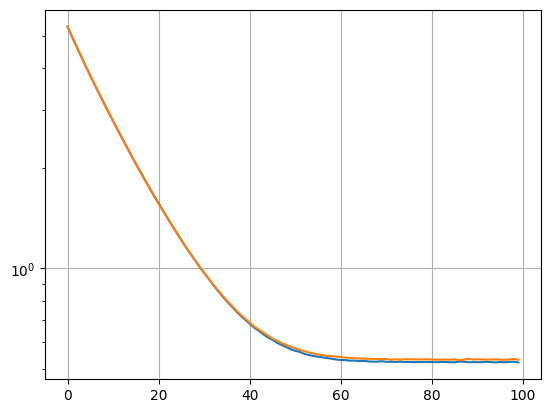

In [40]:
plt.semilogy(train_loss)
plt.semilogy(val_loss)
# plt.plot(train_loss)
# plt.plot(val_loss)
plt.grid()

# Do the prediction
We perform the prediction on the test set.

In [41]:
model.eval()
with torch.no_grad():
    y_ = model(X_test)
print(f"MSE on the test set: {loss_fn(y_test, y_).item()}")
print(f"R2 on the test set: {r2_score( y_.detach().numpy(), y_test.detach().numpy())}")

MSE on the test set: 0.5348429083824158
R2 on the test set: 0.31239188872192625


(0.1499900072813034, 5.000010013580322)

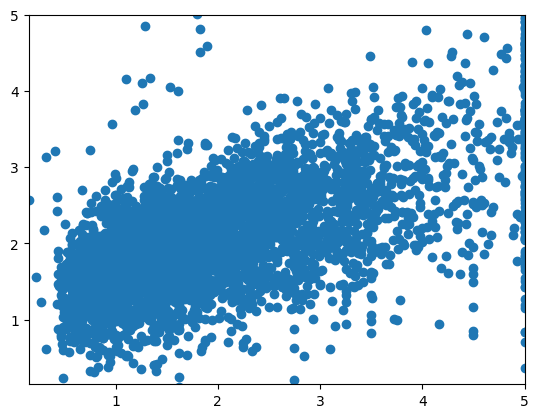

In [13]:
# Plot the scatter plot: prediction as a function of the true values
plt.scatter(y_test.detach().numpy(), y_.detach().numpy())
plt.xlim([y_test.detach().numpy().min(), y_test.detach().numpy().max()])
plt.ylim([y_test.detach().numpy().min(), y_test.detach().numpy().max()])

# TO DO
- Play a little bit with the hyperparameters (learning_rate, batch_size) to improve the accuarcy
- Change the MSE to others loss

In [32]:
X_train.mean(axis=0)

tensor([ 3.8678e+00,  2.8530e+01,  5.4214e+00,  1.0938e+00,  1.4289e+03,
         2.9893e+00,  3.5633e+01, -1.1957e+02])